In [1]:
import numpy as np 
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from glob import glob
import matplotlib as mpl       
import pandas as pd

In [2]:
def lat_lon(filename,skip_line_no,lat,lon):
    df = pd.read_csv(filename,skiprows=skip_line_no,sep='\t')
    df = df.drop(['Event'],axis = 1)
    df['Date/Time'] = pd.to_datetime(df['Date/Time'])
    df= df.where(df['Date/Time'] < '2020-10-01') 
    df = df.resample('60min',on = 'Date/Time').mean()
    lat_arr = df[lat].to_numpy()
    lon_arr = df[lon].to_numpy()
    return(lat_arr,lon_arr)
def read_files(filename,skip_line_no,pollution,var):
    df = pd.read_csv(filename,skiprows=skip_line_no,sep='\t')
    df['Date/Time'] = pd.to_datetime(df['Date/Time'])
    df= df.where(df['Date/Time'] < '2020-10-01') 
    #df = df.drop(['Event'],axis = 1)
    #df = df[df[pollution] != 1]
    df = df.resample('60min',on = 'Date/Time').mean()
    print(df)
    return(df)
def read_files1(filename,skip_line_no,pollution,var):
    df = pd.read_csv(filename,skiprows=skip_line_no,sep='\t')
    df['Date/Time'] = pd.to_datetime(df['Date/Time'])
    df= df.where(df['Date/Time'] < '2020-10-01') 
    df = df.drop(['Event'],axis = 1)
    df = df[df[pollution] != 1]
    df = df.resample('60min',on = 'Date/Time').mean()
    print(df)
    return(df)

In [3]:
# calculates the houly average location of Polarstern
latitude,longitude = lat_lon('../cpc3025_corrected_10s.tab',39,'Latitude','Longitude')

precursors = read_files('../dataset963321.tab',47,'Flag pollution','CP_conc [#/cm**3]')
precursors = precursors.reset_index()
mosaic_vals = read_files1('../cpc3025_pollution_flag_1min(1).tab',43,'Flag','CP_conc [#/cm**3]')
mosaic_vals = mosaic_vals.reset_index()
basecase_vals = xr.open_dataset('../sensitivityanalysis/basecase_pathvals_surface.nc')

                      Latitude   Longitude  H2SO4 [molec/cm**3]  \
Date/Time                                                         
2019-10-20 00:00:00  84.965523  132.824062        111797.940833   
2019-10-20 01:00:00  84.968148  132.799469        123358.500833   
2019-10-20 02:00:00  84.971052  132.779647        106945.180000   
2019-10-20 03:00:00  84.974068  132.764989         87113.391667   
2019-10-20 04:00:00  84.976900  132.754967        115954.265000   
...                        ...         ...                  ...   
2020-09-30 19:00:00  81.255780    2.960164        321554.883333   
2020-09-30 20:00:00  81.155633    3.352254        423812.325833   
2020-09-30 21:00:00  81.059473    3.768359        451925.775000   
2020-09-30 22:00:00  80.976166    4.103166        258855.898333   
2020-09-30 23:00:00  80.960896    4.159506         62693.835833   

                     MSA [molec/cm**3]  HIO3 [molec/cm**3]  Flag pollution  \
Date/Time                                         

/home/chandras/anaconda3/envs/ccnproj/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gini' loading failed:
module 'numpy' has no attribute 'cumproduct'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

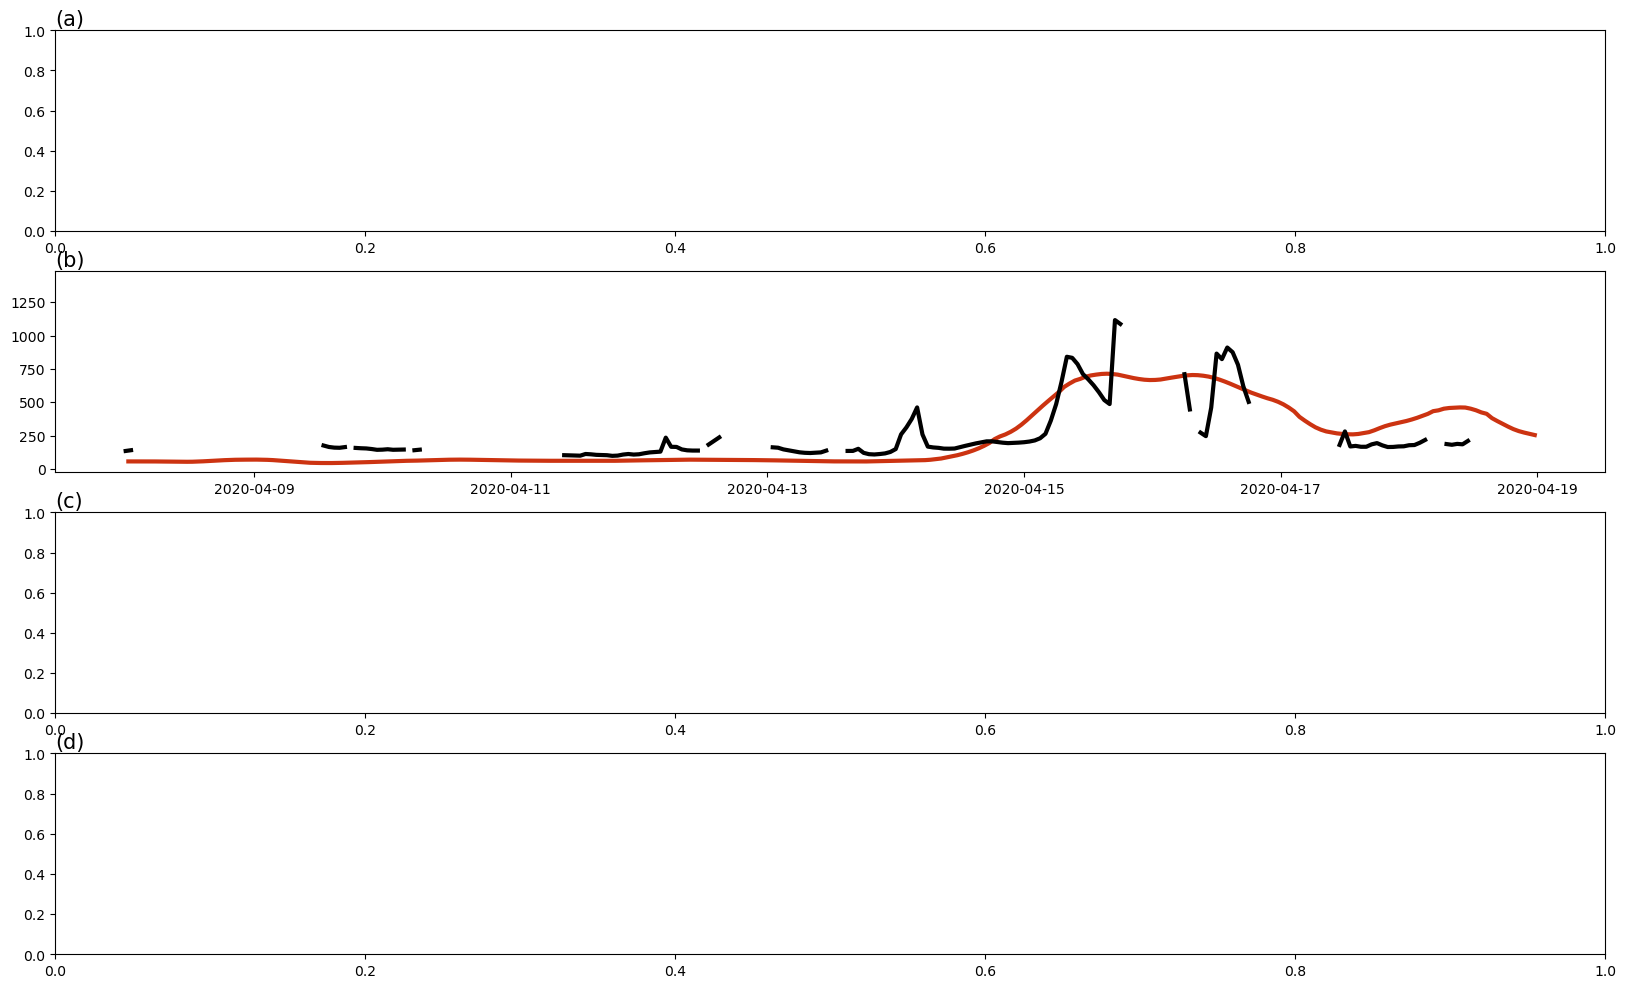

In [7]:
colors = ['#EE7733','#0077BB','#33BBEE','#EE3377','#CC3311','#009988']

fig,ax = plt.subplots(4,figsize = (20,12))
indices = ['(a)','(b)','(c)','(d)']
for i in range(4):
    ax[i].text(0, 1.025,indices[i],transform=ax[i].transAxes,size = 15)
# selecting the dates for the event in MM-DD-YYYY format. xarray and pandas seem to have different methods for setting the end dates. the event_end2 is for xarray, which takes all points during that day whereas pandas takes all values before the given day
event_start = '04-08-2020'
event_end = '04-19-2020'
event_end2 = '04-18-2020'

# creating a time slice for the period we need
mosaic_event = mosaic_vals[(mosaic_vals['Date/Time'] >= pd.to_datetime(event_start)) & (mosaic_vals['Date/Time'] < pd.to_datetime(event_end))]
precursors_event = precursors[(precursors['Date/Time'] >= pd.to_datetime(event_start)) & (precursors['Date/Time'] < pd.to_datetime(event_end))]
basecase_event = basecase_vals.sel(time=slice(event_start, event_end2))
ax[1].plot(basecase_event.time, basecase_event.conccn,label = 'BASECASE',color = colors[4],linewidth = 3)
ax[1].plot(mosaic_event['Date/Time'], mosaic_event['CP_conc [#/cm**3]'],label = 'MOSAiC',color = 'k',linewidth = 3)
axis = ax[0,1].twinx()
axis.plot(mosaic_event['Date/Time'], precursors_event['H2SO4 [molec/cm**3]'],label = 'H2SO4',color = colors[0])
axis.plot(mosaic_event['Date/Time'], precursors_event['MSA [molec/cm**3]'],label = 'MSA',color = colors[1])
axis.plot(mosaic_event['Date/Time'], precursors_event['HIO3 [molec/cm**3]'],label = 'Iodic acid',color = colors[2])

#plt.yscale('log')
ax[0,1].set_xlabel('Day(YYYY-MM-DD)')
#ax[0,1].set_ylabel('Number Concentration (cm⁻³)')


event_start = '12-01-2019'
event_end = '12-14-2019'
event_end2 = '12-13-2019'
mosaic_event = mosaic_vals[(mosaic_vals['Date/Time'] >= pd.to_datetime(event_start)) & (mosaic_vals['Date/Time'] < pd.to_datetime(event_end))]
precursors_event = precursors[(precursors['Date/Time'] >= pd.to_datetime(event_start)) & (precursors['Date/Time'] < pd.to_datetime(event_end))]
basecase_event = basecase_vals.sel(time=slice(event_start, event_end2))
ax[0].plot(basecase_event.time, basecase_event.conccn,label = 'BASECASE',color = colors[4],linewidth = 3)
ax[0].plot(mosaic_event['Date/Time'], mosaic_event['CP_conc [#/cm**3]'],label = 'MOSAiC',color = 'k',linewidth = 3)
axis1 = ax[0,0].twinx()
axis1.plot(mosaic_event['Date/Time'], precursors_event['H2SO4 [molec/cm**3]'],label = 'H2SO4',color = colors[0])
axis1.plot(mosaic_event['Date/Time'], precursors_event['MSA [molec/cm**3]'],label = 'MSA',color = colors[1])
axis1.plot(mosaic_event['Date/Time'], precursors_event['HIO3 [molec/cm**3]'],label = 'Iodic acid',color = colors[2])
ax[0,0].set_xlabel('Day(YYYY-MM-DD)')
#ax[0,0].set_ylabel('Number Concentration(cm⁻³)')
#ax[0,0]yscale('log')
ax[0,0].legend(loc = 'upper left')
axis1.legend(loc = 'upper right')

event_start = '06-29-2020'
event_end = '07-04-2020'
event_end2 = '07-03-2020'
mosaic_event = mosaic_vals[(mosaic_vals['Date/Time'] >= pd.to_datetime(event_start)) & (mosaic_vals['Date/Time'] < pd.to_datetime(event_end))]
precursors_event = precursors[(precursors['Date/Time'] >= pd.to_datetime(event_start)) & (precursors['Date/Time'] < pd.to_datetime(event_end))]
basecase_event = basecase_vals.sel(time=slice(event_start, event_end2))
ax[2].plot(basecase_event.time, basecase_event.conccn,label = 'BASECASE',color = colors[4],linewidth = 3)
ax[2].plot(mosaic_event['Date/Time'], mosaic_event['CP_conc [#/cm**3]'],label = 'MOSAiC',color = 'k',linewidth = 3)
axis2 = ax[1,0].twinx()
axis2.plot(mosaic_event['Date/Time'], precursors_event['H2SO4 [molec/cm**3]'],label = 'H2SO4',color = colors[0])
axis2.plot(mosaic_event['Date/Time'], precursors_event['MSA [molec/cm**3]'],label = 'MSA',color = colors[1])
axis2.plot(mosaic_event['Date/Time'], precursors_event['HIO3 [molec/cm**3]'],label = 'Iodic acid',color = colors[2])
#plt.fill_between(basecase_event.time,0, basecase_rolling.conccn, color='b', alpha=0.1)
ax[1,0].set_xlabel('Day(YYYY-MM-DD)')
#ax[1,0].set_ylabel('Aerosol Number Concentration(#/cm³)')



event_start = '09-08-2020'
event_end = '09-16-2020'
event_end2 = '09-15-2020'
mosaic_event = mosaic_vals[(mosaic_vals['Date/Time'] >= pd.to_datetime(event_start)) & (mosaic_vals['Date/Time'] < pd.to_datetime(event_end))]
precursors_event = precursors[(precursors['Date/Time'] >= pd.to_datetime(event_start)) & (precursors['Date/Time'] < pd.to_datetime(event_end))]
basecase_event = basecase_vals.sel(time=slice(event_start, event_end2))
ax[3].plot(basecase_event.time, basecase_event.conccn,label = 'BASECASE',color = colors[4],linewidth = 3)
ax[3].plot(mosaic_event['Date/Time'], mosaic_event['CP_conc [#/cm**3]'],label = 'MOSAiC',color = 'k',linewidth = 3)
axis3 = ax[1,1].twinx()
axis3.plot(mosaic_event['Date/Time'], precursors_event['H2SO4 [molec/cm**3]'],label = 'H2SO4',color = colors[0])
axis3.plot(mosaic_event['Date/Time'], precursors_event['MSA [molec/cm**3]'],label = 'MSA',color = colors[1])
axis3.plot(mosaic_event['Date/Time'], precursors_event['HIO3 [molec/cm**3]'],label = 'Iodic acid',color = colors[2])
#plt.fill_between(basecase_event.time,0, basecase_rolling.conccn, color='b', alpha=0.1)
ax[1,1].set_xlabel('Day(YYYY-MM-DD)')
plt.tight_layout()
fig.subplots_adjust(left=0.1)
fig.text(-0.07, 0, 'Number Concentration (cm⁻³)', va='bottom', ha='center',rotation='vertical', rotation_mode='anchor',transform=ax[0,0].transAxes,fontsize = 15)
#ax[1,1].set_ylabel('Aerosol Number Concentration(#/cm³)')
#plt.yscale('log')

#plt.show()
plt.savefig('../figures/aerosol_events_precursors_wpollution2.jpg',dpi = 300)
